# IMPORT LIBRARIES & LOAD DATASET

In [2]:
import pandas as pd
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [70]:
womens_world_cup_stats = pd.read_csv(
    '/Users/gui/womens_world_cup_2023_statsbomb_finalfinal.csv'
)

In [72]:
womens_world_cup_stats

,match_id,team,match_date,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,dribbles,successful_dribbles,dribble_success_pct,duels,duels_won,counterpress_actions,goals_from_shots,own_goals_for,own_goals_against,goal_type
0,3893787,New Zealand Women's,2023-07-20,Norway Women's,Group,1,0,W,3,57.781529,...,13,6,46.15,59,13,65,1,0,0,Goal
1,3893787,Norway Women's,2023-07-20,New Zealand Women's,Group,0,1,L,0,42.218471,...,21,8,38.10,47,12,55,0,0,0,Goal
2,3893788,Australia Women's,2023-07-20,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,21,12,57.14,34,12,47,1,0,0,Goal
3,3893788,Republic of Ireland Women's,2023-07-20,Australia Women's,Group,0,1,L,0,41.986622,...,10,3,30.00,48,15,73,0,0,0,Goal
4,3893789,Philippines Women's,2023-07-21,Switzerland Women's,Group,0,2,L,0,30.212373,...,11,7,63.64,29,5,74,0,0,0,Goal
5,3893789,Switzerland Women's,2023-07-21,Philippines Women's,Group,2,0,W,3,69.787627,...,13,8,61.54,27,9,43,2,0,0,Goal
6,3893790,Canada Women's,2023-07-21,Nigeria Women's,Group,0,0,D,1,65.692595,...,22,10,45.45,31,11,60,0,0,0,Goal
7,3893790,Nigeria Women's,2023-07-21,Canada Women's,Group,0,0,D,1,34.307405,...,8,5,62.50,49,11,49,0,0,0,Goal
8,3893791,Costa Rica Women's,2023-07-21,Spain Women's,Group,0,3,L,0,16.231330,...,7,0,0.00,58,8,36,0,0,1,Goal
9,3893791,Spain Women's,2023-07-21,Costa Rica Women's,Group,3,0,W,3,83.768670,...,30,19,63.33,25,6,59,2,1,0,Goal + Own Goal


# FILTER SEMI-FINALS

In [74]:
semi_finals = womens_world_cup_stats[
    womens_world_cup_stats['stage'] == 'Semi-finals'
]

In [76]:
games = womens_world_cup_stats[
    womens_world_cup_stats["stage"] == "Semi-finals"
]

games[
    ["match_id", "team", "opponent", "stage"]
].drop_duplicates("match_id")

,match_id,team,opponent,stage
120,3904628,Spain Women's,Sweden Women's,Semi-finals
122,3904629,Australia Women's,England Women's,Semi-finals


# GAME ANALYSIS SPA-SWE

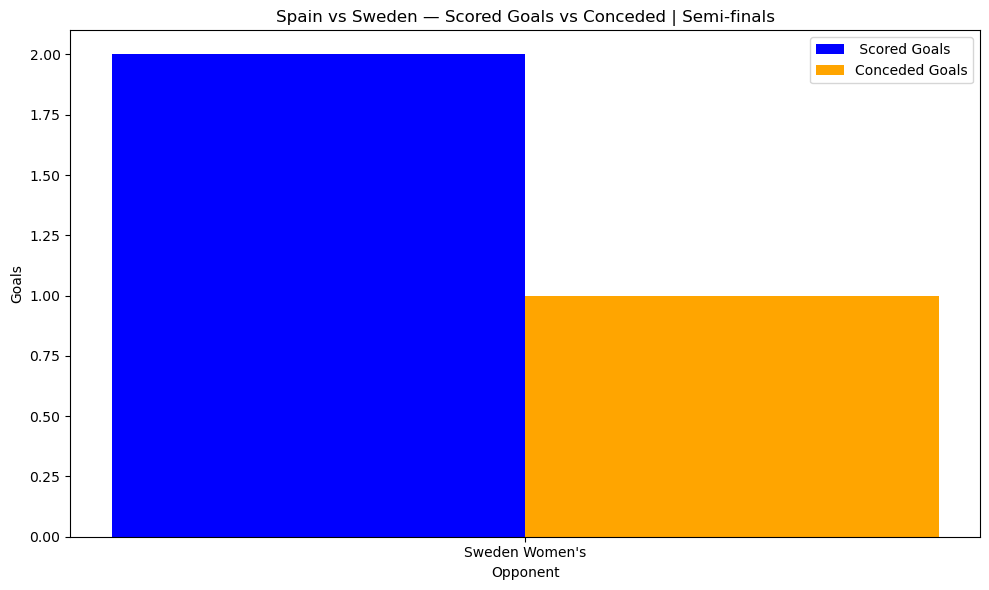

In [115]:
semi_finals = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Spain Women's") &
    (womens_world_cup_stats["stage"] == "Semi-finals")
].copy()

semi_finals["match_date"] = pd.to_datetime(semi_finals["match_date"])

semi_finals = semi_finals.sort_values("match_date")

x = np.arange(len(semi_finals))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    semi_finals["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    semi_finals["goals_against"],
    width,
    label= "Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    semi_finals["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Spain vs Sweden — Scored Goals vs Conceded | Semi-finals")

plt.legend()

plt.tight_layout()
plt.show()

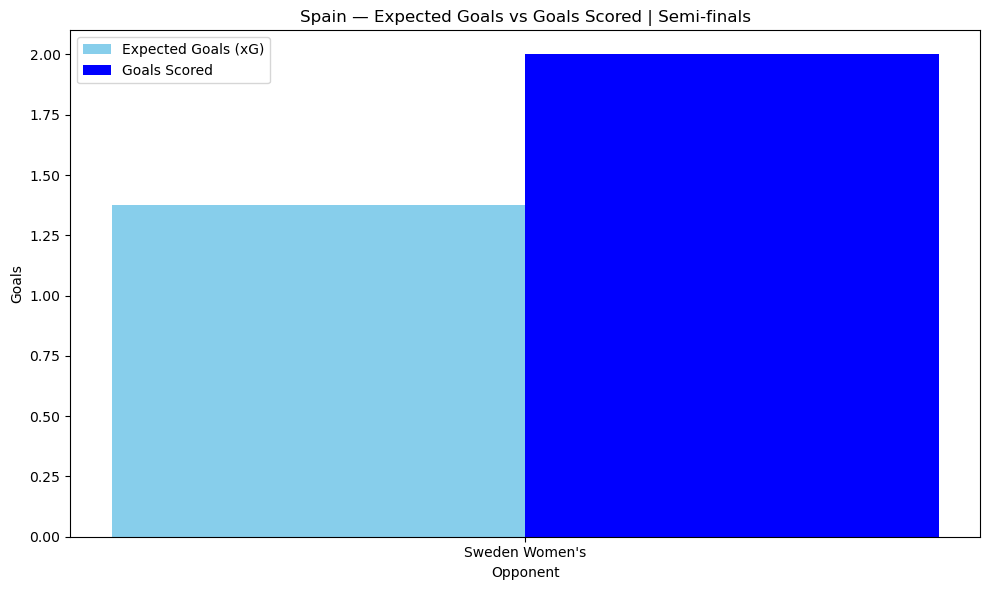

In [117]:
semi_finals = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Spain Women's") &
    (womens_world_cup_stats["stage"] == "Semi-finals")
].copy()

semi_finals["match_date"] = pd.to_datetime(semi_finals["match_date"])

semi_finals = semi_finals.sort_values("match_date")

x = np.arange(len(semi_finals))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    semi_finals["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    semi_finals["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    semi_finals["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Spain — Expected Goals vs Goals Scored | Semi-finals")

plt.legend()

plt.tight_layout()
plt.show()

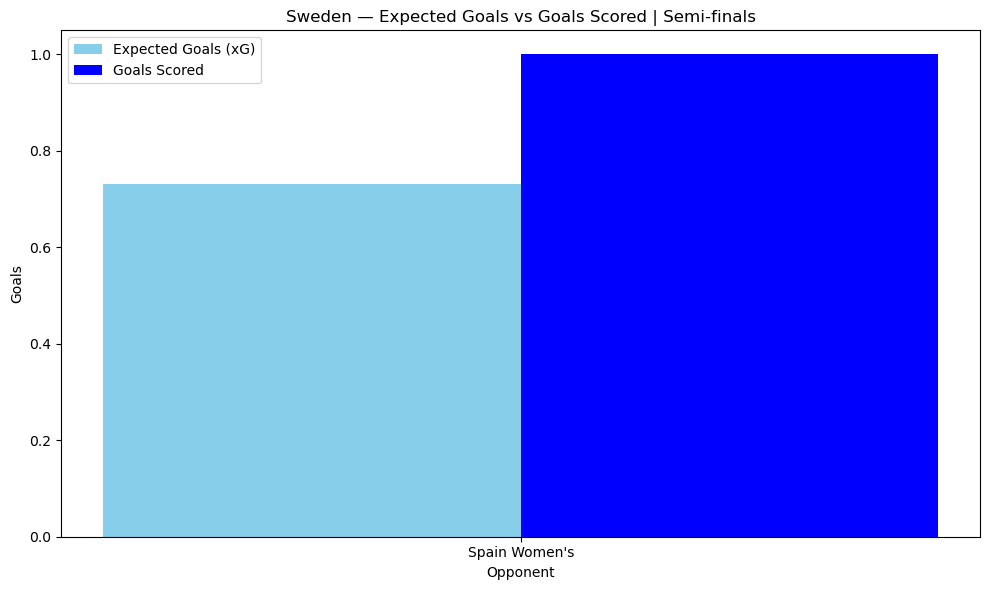

In [119]:
semi_finals = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Sweden Women's") &
    (womens_world_cup_stats["stage"] == "Semi-finals")
].copy()

semi_finals["match_date"] = pd.to_datetime(semi_finals["match_date"])

semi_finals = semi_finals.sort_values("match_date")

x = np.arange(len(semi_finals))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    semi_finals["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    semi_finals["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    semi_finals["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Sweden — Expected Goals vs Goals Scored | Semi-finals")

plt.legend()

plt.tight_layout()
plt.show()

In [84]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Spain Women's") &
        (womens_world_cup_stats["opponent"] == "Sweden Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Sweden Women's") &
        (womens_world_cup_stats["opponent"] == "Spain Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries",
    "Goals from Shots": "goals_from_shots",
    "Own Goals From": "own_goals_for",	
    "Own Goals Against": "own_goals_against",	
    "Goal type": "goal_type"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Spain": [
        match.loc[
            match["team"] == "Spain Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Sweden": [
        match.loc[
            match["team"] == "Sweden Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Spain", "Sweden"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Spain", "Sweden"]
].round(1)


# Display table

comparison

,Metric,Spain,Sweden
0,Goals,2,1
1,xG,1.375955,0.731733
2,Goals Minus xG,0.624045,0.268267
3,Shots,13,6
4,Shots on Target,2,3
5,Saves,2,0
6,Possession %,57.098515,42.901485
7,Pass Accuracy %,78.711986,63.114754
8,Progressive Passes,131.0,101.0
9,Progressive Carries,16.0,16.0


Teams found:
["Spain Women's" "Sweden Women's"]


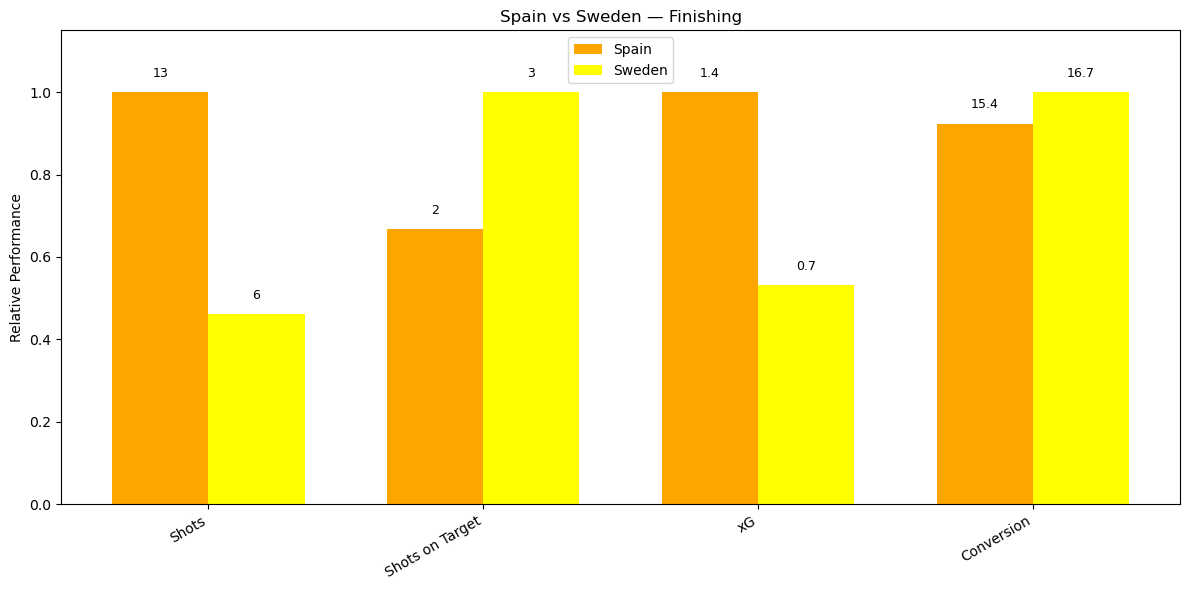

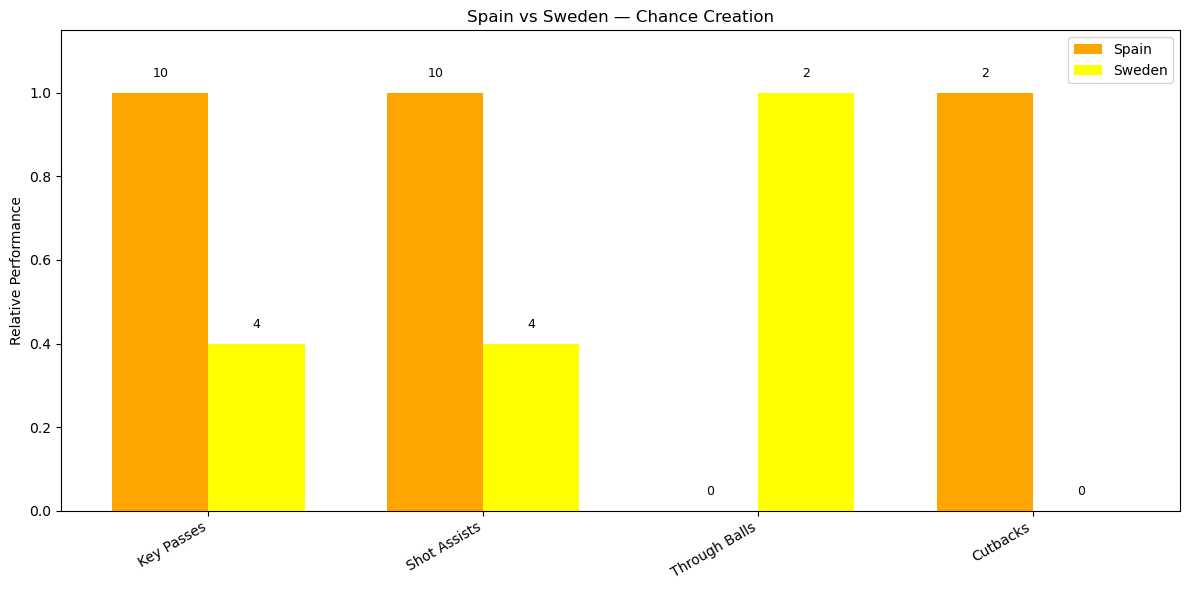

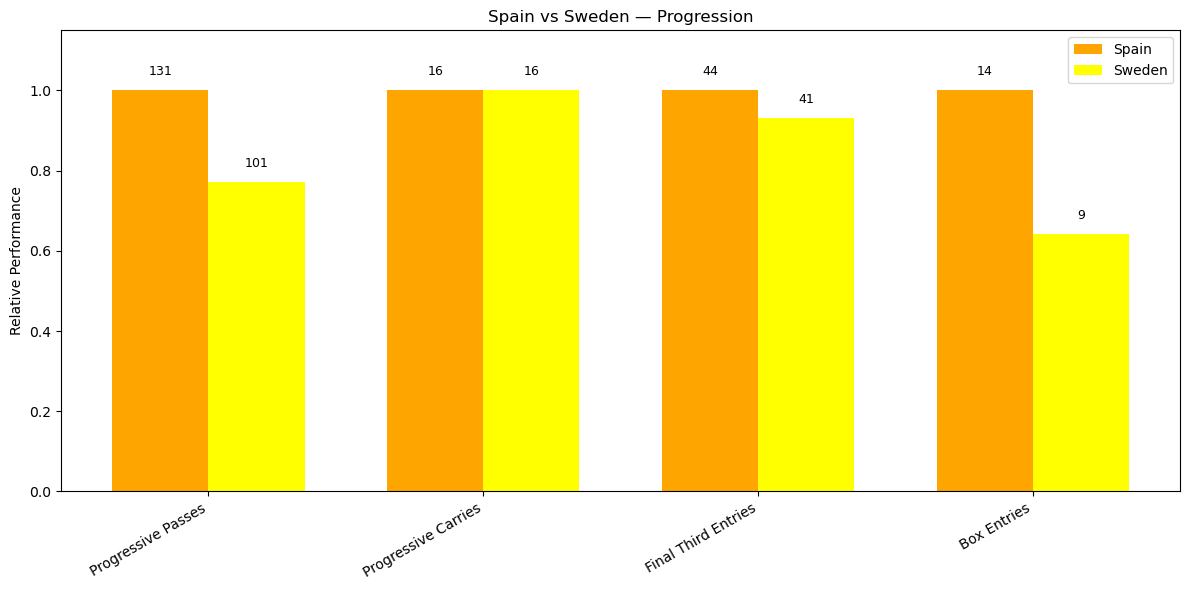

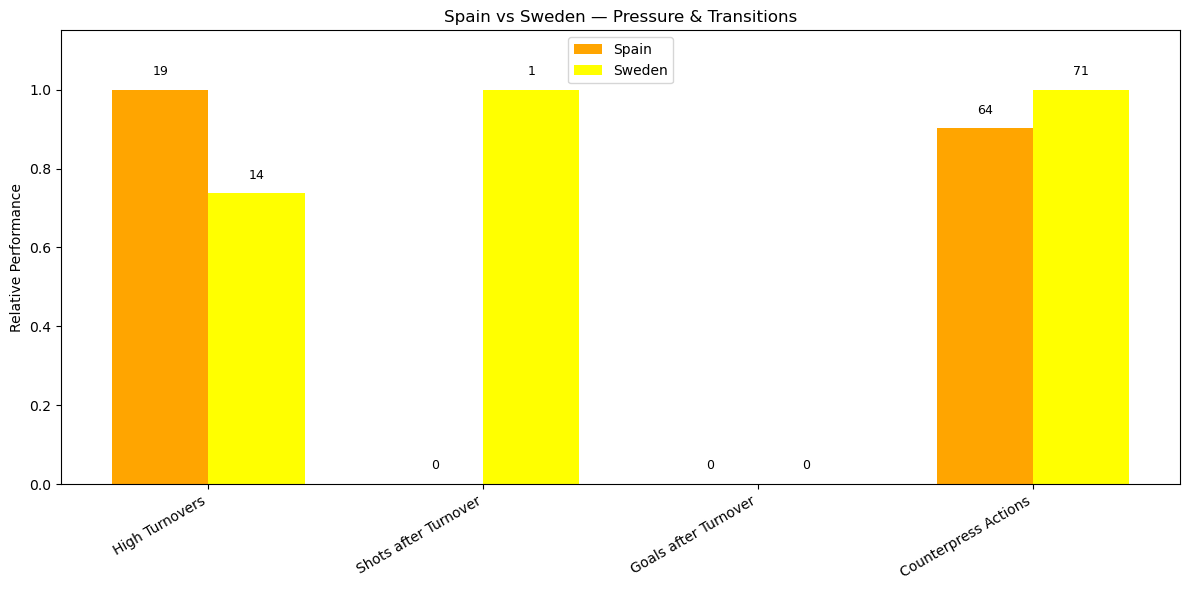

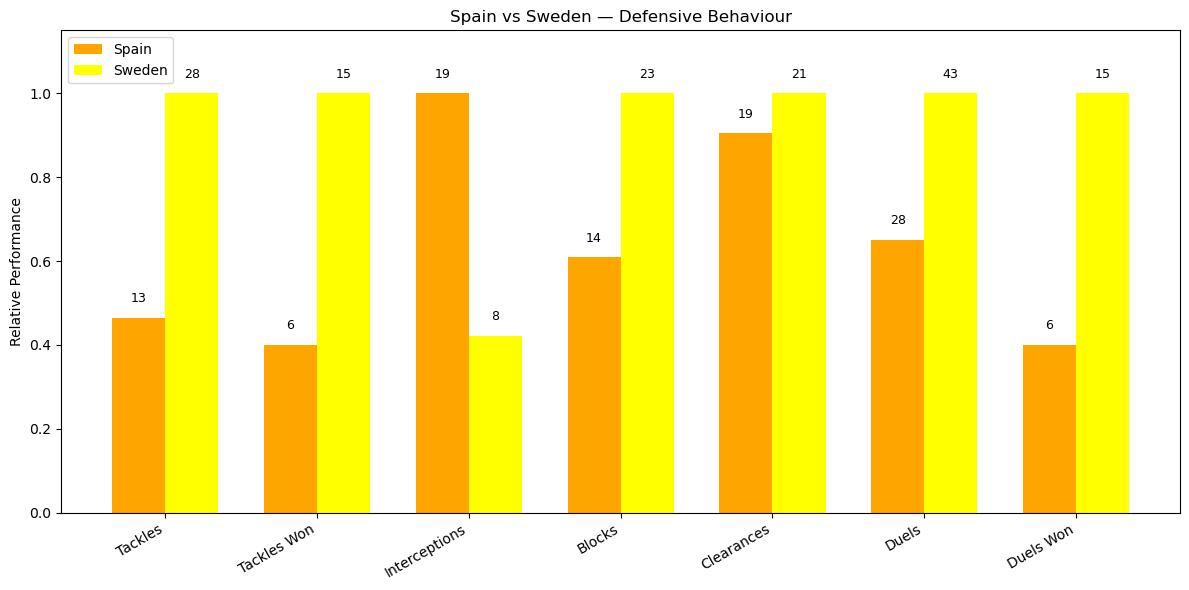

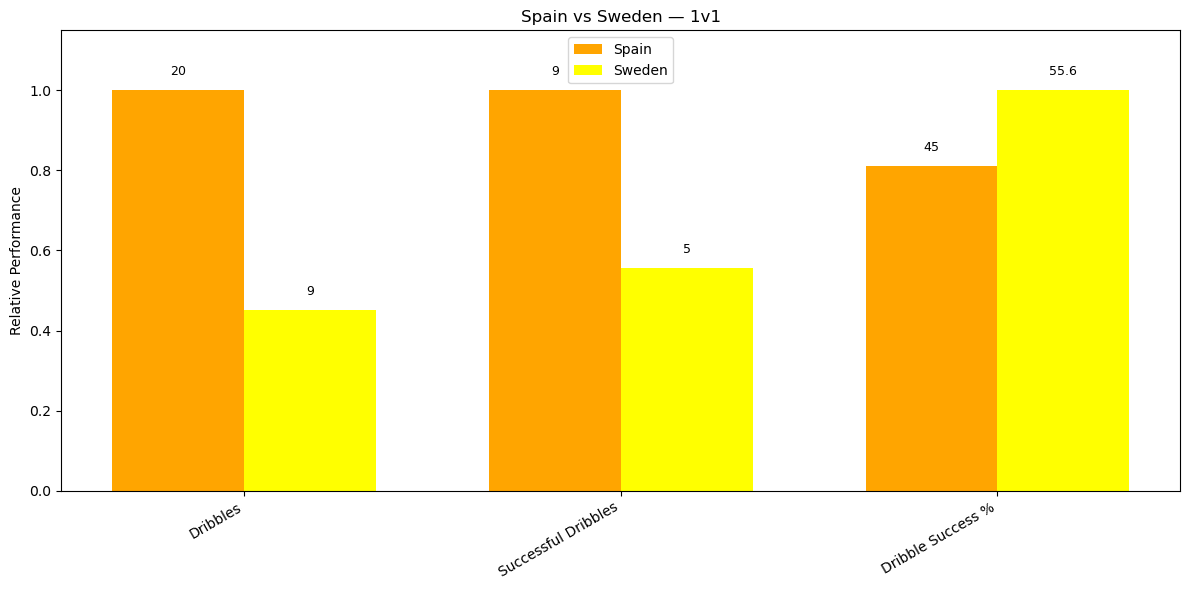

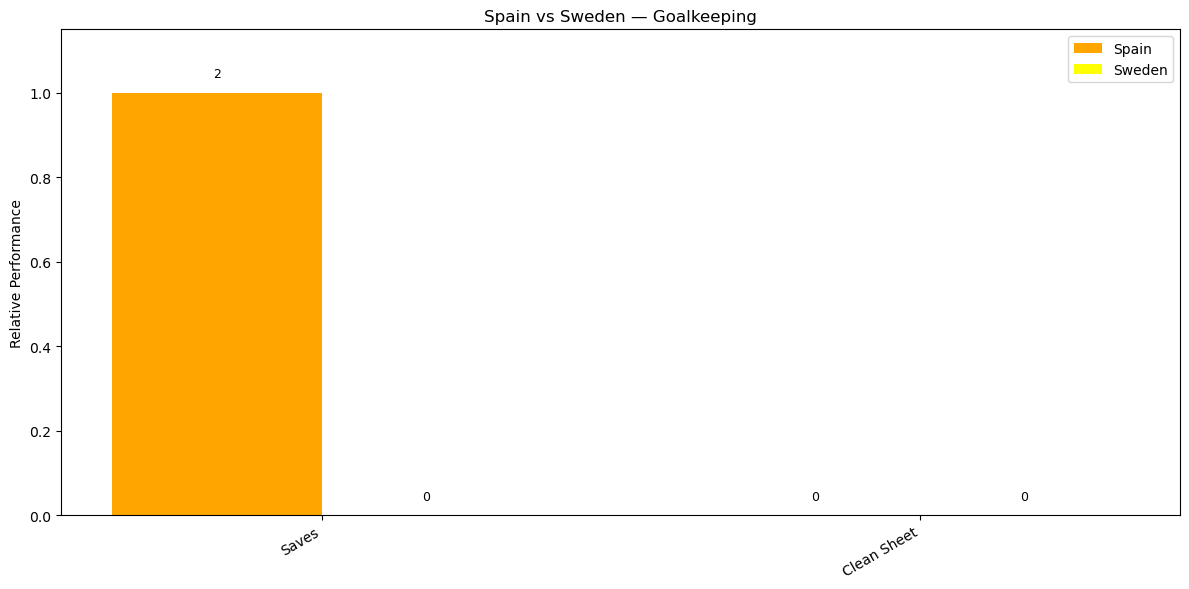

In [88]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (
            (womens_world_cup_stats["team"] == "Spain Women's") &
            (womens_world_cup_stats["opponent"] == "Sweden Women's")
        )
        |
        (
            (womens_world_cup_stats["team"] == "Sweden Women's") &
            (womens_world_cup_stats["opponent"] == "Spain Women's")
        )
    )
    &
    (womens_world_cup_stats["stage"] == "Semi-finals")
].copy()


# ============================================================
# 2. TEAM NAMES
# ============================================================

team_names = {
    "Spain": "Spain Women's",
    "Sweden": "Sweden Women's"
}


# ============================================================
# 3. METRICS BY CATEGORY
# ============================================================

categories = {


    "Finishing": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "xG": "xG",
        "Conversion": "conversion_pct"
    },


     "Chance Creation": {
        "Key Passes": "key_passes",
        "Shot Assists": "shot_assists",
        "Through Balls": "through_balls",
        "Cutbacks": "cutbacks"
    },



    "Progression": {
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries"
    },



    "Pressure & Transitions": {
        "High Turnovers": "high_turnovers",
        "Shots after Turnover": "shots_after_turnover",
        "Goals after Turnover": "goals_after_turnover",
        "Counterpress Actions": "counterpress_actions"
    },



    "Defensive Behaviour": {
        "Tackles": "tackles",
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Duels": "duels",
        "Duels Won": "duels_won"
    },



    "1v1": {
        "Dribbles": "dribbles",
        "Successful Dribbles": "successful_dribbles",
        "Dribble Success %": "dribble_success_pct"
    },



    "Goalkeeping": {
        "Saves": "saves",
        "Clean Sheet": "clean_sheet"
    }
}


# ============================================================
# 4. CHECK TEAMS
# ============================================================

print("Teams found:")
print(match["team"].unique())


# ============================================================
# 5. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # --------------------------------------------------------
    # Get real values
    # --------------------------------------------------------

    spa_values = np.array([
        match.loc[
            match["team"] == team_names["Spain"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    swe_values = np.array([
        match.loc[
            match["team"] == team_names["Sweden"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    # --------------------------------------------------------
    # Maximum value for each metric
    # --------------------------------------------------------

    max_values = np.maximum(
        spa_values,
        swe_values
    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    spa_normalized = np.divide(
        spa_values,
        max_values,
        out=np.zeros_like(spa_values),
        where=max_values != 0
    )


    swe_normalized = np.divide(
        swe_values,
        max_values,
        out=np.zeros_like(swe_values),
        where=max_values != 0
    )


    # --------------------------------------------------------
    # Position of bars
    # --------------------------------------------------------

    x = np.arange(len(metrics))
    width = 0.35


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))


    bars_spa = plt.bar(
        x - width / 2,
        spa_normalized,
        width,
        label="Spain",
        color="orange"
    )


    bars_swe = plt.bar(
        x + width / 2,
        swe_normalized,
        width,
        label="Sweden",
        color="yellow"
    )


    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(
        bars_spa,
        spa_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    for bar, value in zip(
        bars_swe,
        swe_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Spain vs Sweden — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [90]:
match[[
    "team",
    "opponent",
    "formation"
]]

,team,opponent,formation
120,Spain Women's,Sweden Women's,4-3-3
121,Sweden Women's,Spain Women's,4-2-3-1


In [94]:
formation_comparison = pd.DataFrame({
    "Metric": [
        "Formation",
        "Possession %",
        "Shots",
        "xG",
        "Progressive Passes",
        "Progressive Carries",
        "Final Third Entries",
        "Box Entries",
        "High Turnovers",
        "Interceptions",
        "Clearances"
    ],

    "Spain": [
        match.loc[
            match["team"] == "Spain Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "clearances"
        ].iloc[0]
    ],

    "Sweden": [
        match.loc[
            match["team"] == "Sweden Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "clearances"
        ].iloc[0]
    ]
})

# Arredondar percentagens e xG
formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Spain", "Sweden"]
] = formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Spain", "Sweden"]
].round(1)

formation_comparison

,Metric,Spain,Sweden
0,Formation,4-3-3,4-2-3-1
1,Possession %,57.098515,42.901485
2,Shots,13,6
3,xG,1.375955,0.731733
4,Progressive Passes,131.0,101.0
5,Progressive Carries,16.0,16.0
6,Final Third Entries,44.0,41.0
7,Box Entries,14.0,9.0
8,High Turnovers,19.0,14.0
9,Interceptions,19,8


## Conclusion SPA-SWE

It was a fairly balanced game, with similar numbers in progression and pressure metrics. Spain had slightly more possession and attacking volume, with more progressive passes, final-third entries and box entries. In attack, Spain created more opportunities, but despite scoring twice from 13 shots, only two were on target, meaning their shot accuracy was relatively low. Sweden, on the other hand, had fewer attempts but a higher shot accuracy and slightly better conversion rate. Both teams finished above their xG, although Spain's Goals Minus xG was considerably higher.

Defensively, Sweden stood out with significantly more tackles won, blocks and clearances, reflecting a more defensive and reactive approach. However, this defensive effort did not prevent Spain from scoring, while Sweden's goalkeeper did not record a single save. The formations also suggest different approaches: Sweden's 4-2-3-1 provided a clear central attacking structure, while Spain's 4-3-3 offered more width and attacking progression. Nevertheless, Spain did not dominate territorially as much as might be expected from the formation, with both teams remaining relatively close in several progression metrics.

# GAME ANALYSIS AUS-ENG

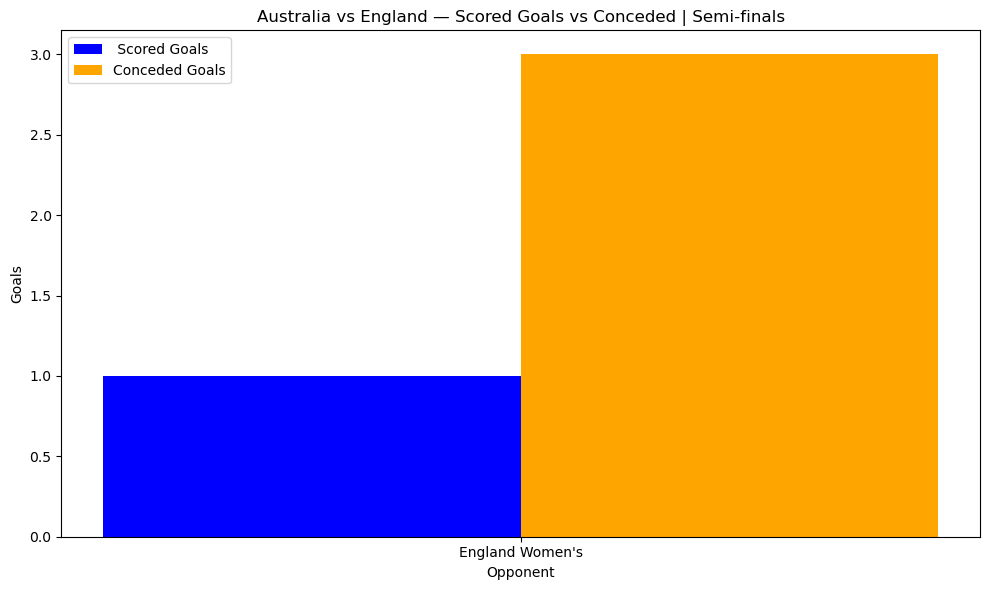

In [121]:
semi_finals = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Australia Women's") &
    (womens_world_cup_stats["stage"] == "Semi-finals")
].copy()

semi_finals["match_date"] = pd.to_datetime(semi_finals["match_date"])

semi_finals = semi_finals.sort_values("match_date")

x = np.arange(len(semi_finals))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    semi_finals["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    semi_finals["goals_against"],
    width,
    label= "Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    semi_finals["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Australia vs England — Scored Goals vs Conceded | Semi-finals")

plt.legend()

plt.tight_layout()
plt.show()

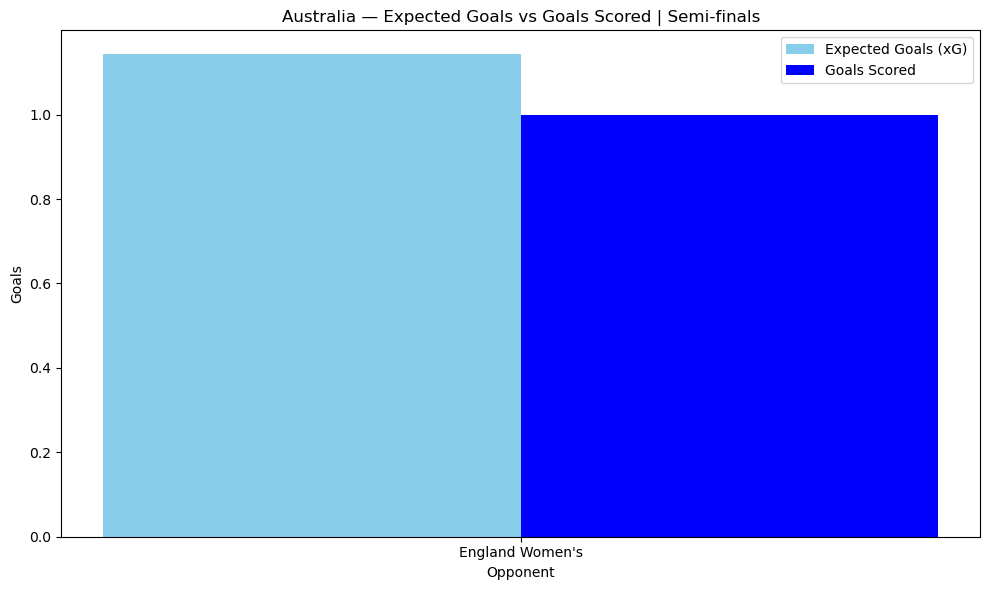

In [123]:
semi_finals = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Australia Women's") &
    (womens_world_cup_stats["stage"] == "Semi-finals")
].copy()

semi_finals["match_date"] = pd.to_datetime(semi_finals["match_date"])

semi_finals = semi_finals.sort_values("match_date")

x = np.arange(len(semi_finals))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    semi_finals["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    semi_finals["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    semi_finals["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Australia — Expected Goals vs Goals Scored | Semi-finals")

plt.legend()

plt.tight_layout()
plt.show()

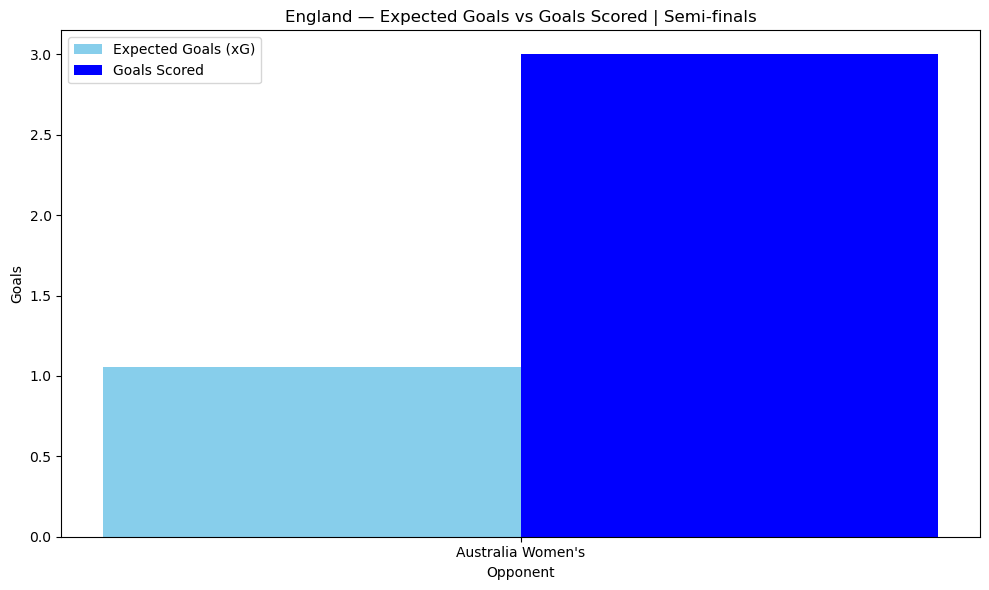

In [125]:
semi_finals = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "England Women's") &
    (womens_world_cup_stats["stage"] == "Semi-finals")
].copy()

semi_finals["match_date"] = pd.to_datetime(semi_finals["match_date"])

semi_finals = semi_finals.sort_values("match_date")

x = np.arange(len(semi_finals))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    semi_finals["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    semi_finals["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    semi_finals["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("England — Expected Goals vs Goals Scored | Semi-finals")

plt.legend()

plt.tight_layout()
plt.show()

In [105]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Australia Women's") &
        (womens_world_cup_stats["opponent"] == "England Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "England Women's") &
        (womens_world_cup_stats["opponent"] == "Australia Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries",
    "Goals from Shots": "goals_from_shots",
    "Own Goals From": "own_goals_for",	
    "Own Goals Against": "own_goals_against",	
    "Goal type": "goal_type"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Australia": [
        match.loc[
            match["team"] == "Australia Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "England": [
        match.loc[
            match["team"] == "England Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Australia", "England"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Australia", "England"]
].round(1)


# Display table

comparison

,Metric,Australia,England
0,Goals,1,3
1,xG,1.142442,1.052779
2,Goals Minus xG,-0.142442,1.947221
3,Shots,12,15
4,Shots on Target,4,5
5,Saves,2,3
6,Possession %,50.028477,49.971523
7,Pass Accuracy %,71.722365,83.170254
8,Progressive Passes,98.0,131.0
9,Progressive Carries,12.0,25.0


Teams found:
["Australia Women's" "England Women's"]


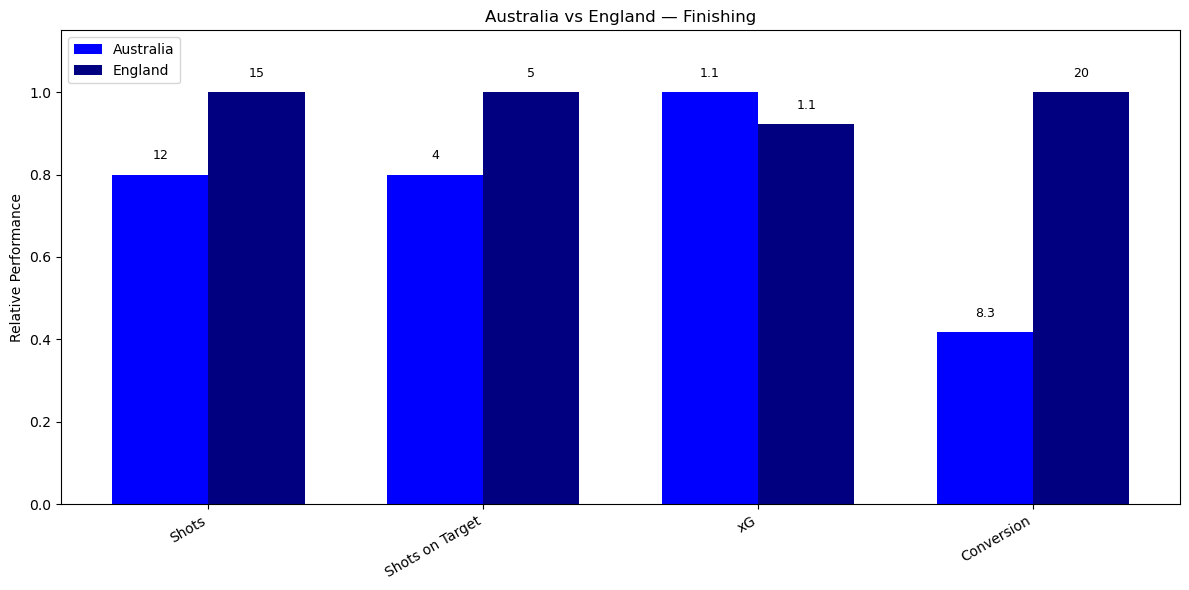

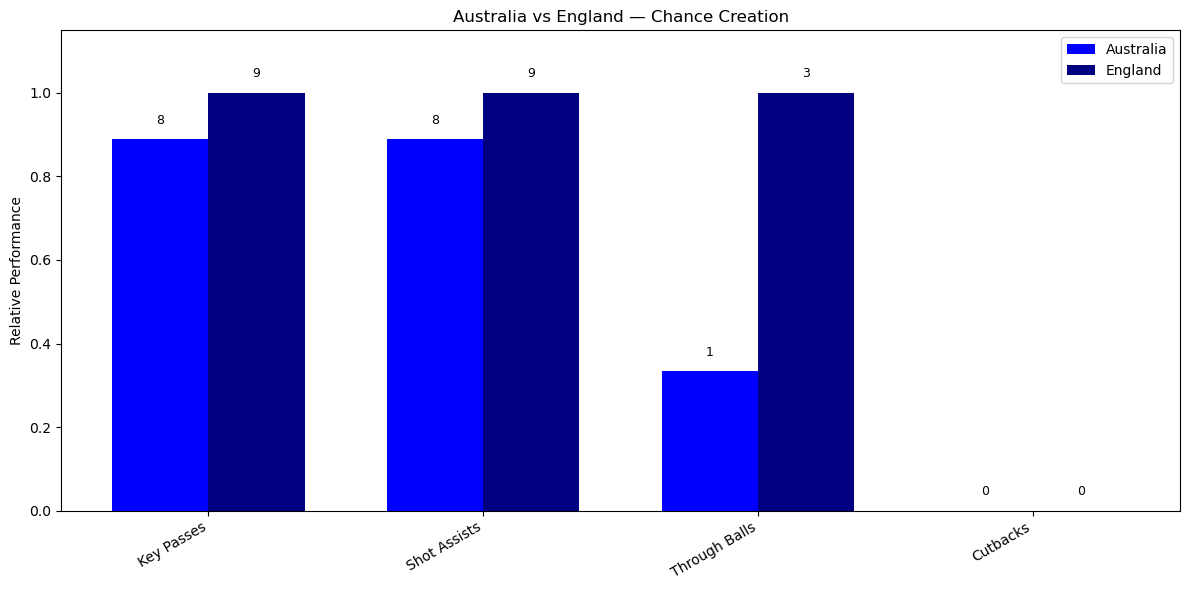

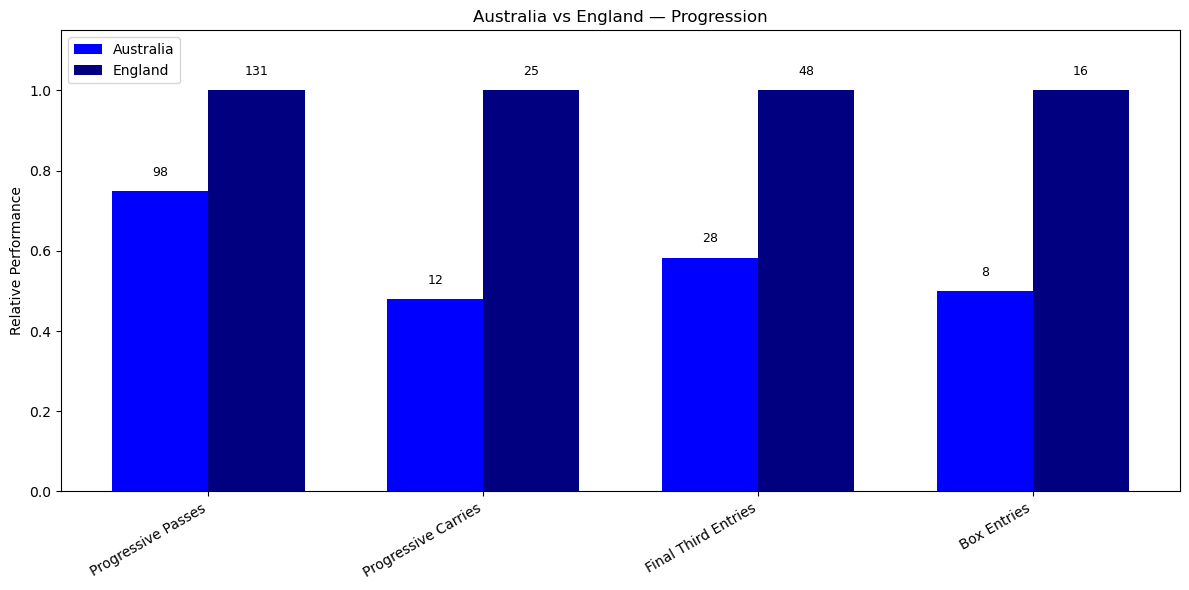

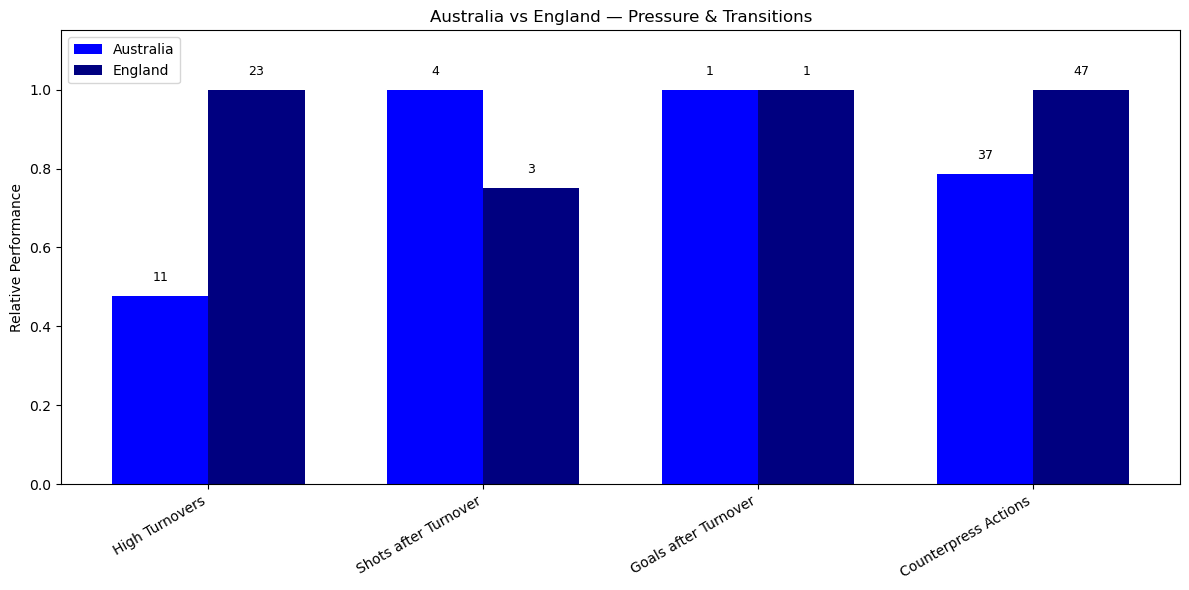

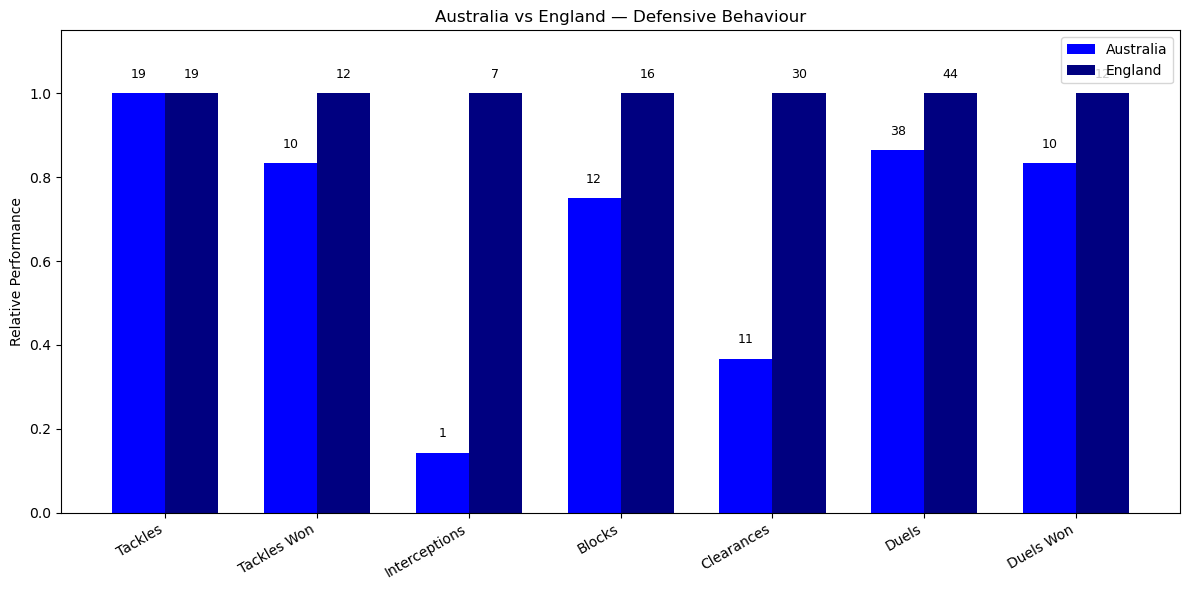

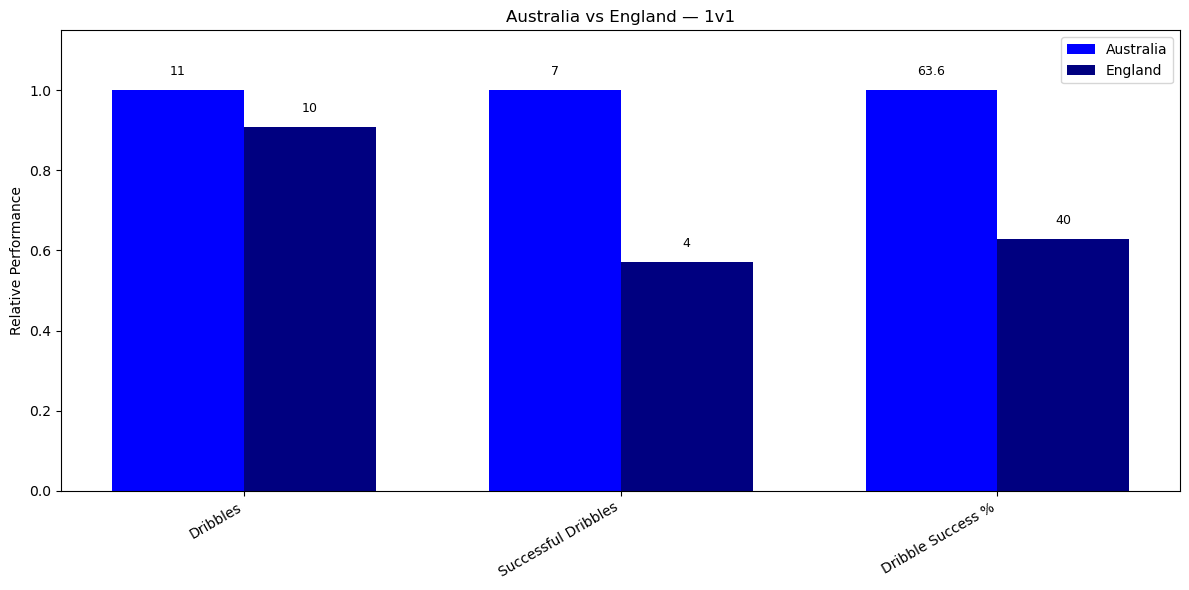

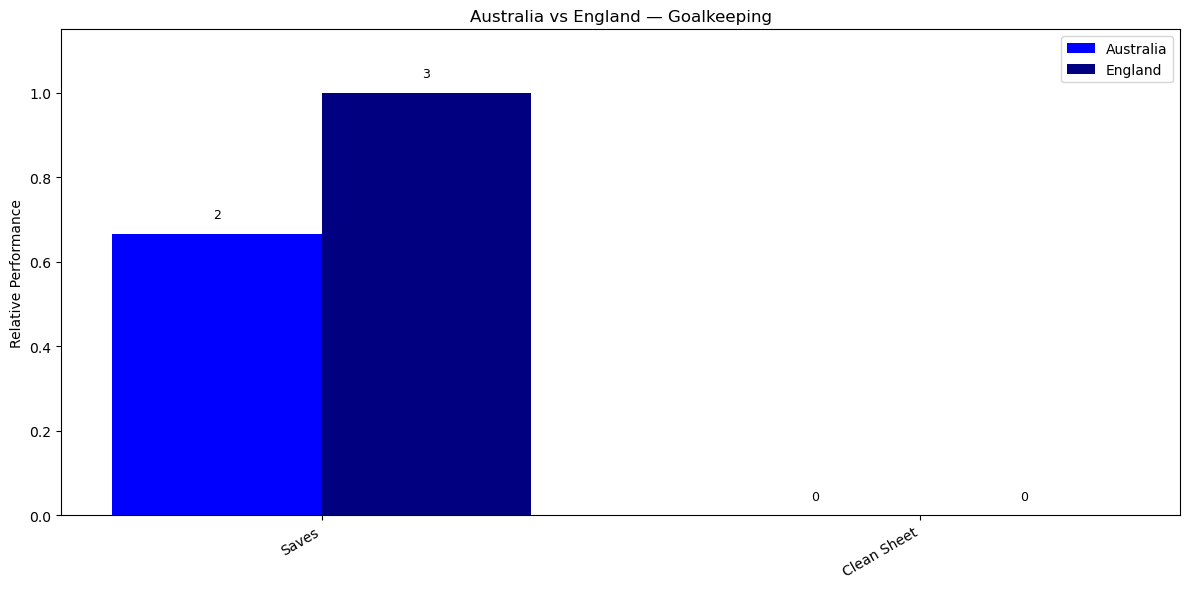

In [107]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (
            (womens_world_cup_stats["team"] == "Australia Women's") &
            (womens_world_cup_stats["opponent"] == "England Women's")
        )
        |
        (
            (womens_world_cup_stats["team"] == "England Women's") &
            (womens_world_cup_stats["opponent"] == "Australia Women's")
        )
    )
    &
    (womens_world_cup_stats["stage"] == "Semi-finals")
].copy()


# ============================================================
# 2. TEAM NAMES
# ============================================================

team_names = {
    "Australia": "Australia Women's",
    "England": "England Women's"
}


# ============================================================
# 3. METRICS BY CATEGORY
# ============================================================

categories = {


    "Finishing": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "xG": "xG",
        "Conversion": "conversion_pct"
    },


     "Chance Creation": {
        "Key Passes": "key_passes",
        "Shot Assists": "shot_assists",
        "Through Balls": "through_balls",
        "Cutbacks": "cutbacks"
    },



    "Progression": {
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries"
    },



    "Pressure & Transitions": {
        "High Turnovers": "high_turnovers",
        "Shots after Turnover": "shots_after_turnover",
        "Goals after Turnover": "goals_after_turnover",
        "Counterpress Actions": "counterpress_actions"
    },



    "Defensive Behaviour": {
        "Tackles": "tackles",
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Duels": "duels",
        "Duels Won": "duels_won"
    },



    "1v1": {
        "Dribbles": "dribbles",
        "Successful Dribbles": "successful_dribbles",
        "Dribble Success %": "dribble_success_pct"
    },



    "Goalkeeping": {
        "Saves": "saves",
        "Clean Sheet": "clean_sheet"
    }
}


# ============================================================
# 4. CHECK TEAMS
# ============================================================

print("Teams found:")
print(match["team"].unique())


# ============================================================
# 5. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # --------------------------------------------------------
    # Get real values
    # --------------------------------------------------------

    aus_values = np.array([
        match.loc[
            match["team"] == team_names["Australia"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    eng_values = np.array([
        match.loc[
            match["team"] == team_names["England"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    # --------------------------------------------------------
    # Maximum value for each metric
    # --------------------------------------------------------

    max_values = np.maximum(
        aus_values,
        eng_values
    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    aus_normalized = np.divide(
        aus_values,
        max_values,
        out=np.zeros_like(aus_values),
        where=max_values != 0
    )


    eng_normalized = np.divide(
        eng_values,
        max_values,
        out=np.zeros_like(eng_values),
        where=max_values != 0
    )


    # --------------------------------------------------------
    # Position of bars
    # --------------------------------------------------------

    x = np.arange(len(metrics))
    width = 0.35


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))


    bars_aus = plt.bar(
        x - width / 2,
        aus_normalized,
        width,
        label="Australia",
        color="blue"
    )


    bars_eng = plt.bar(
        x + width / 2,
        eng_normalized,
        width,
        label="England",
        color="navy"
    )


    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(
        bars_aus,
        aus_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    for bar, value in zip(
        bars_eng,
        eng_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Australia vs England — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [109]:
match[[
    "team",
    "opponent",
    "formation"
]]

,team,opponent,formation
122,Australia Women's,England Women's,4-4-2
123,England Women's,Australia Women's,3-4-1-2


In [111]:
formation_comparison = pd.DataFrame({
    "Metric": [
        "Formation",
        "Possession %",
        "Shots",
        "xG",
        "Progressive Passes",
        "Progressive Carries",
        "Final Third Entries",
        "Box Entries",
        "High Turnovers",
        "Interceptions",
        "Clearances"
    ],

    "Australia": [
        match.loc[
            match["team"] == "Australia Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "clearances"
        ].iloc[0]
    ],

    "England": [
        match.loc[
            match["team"] == "England Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "clearances"
        ].iloc[0]
    ]
})

# Arredondar percentagens e xG
formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Australia", "England"]
] = formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Australia", "England"]
].round(1)

formation_comparison

,Metric,Australia,England
0,Formation,4-4-2,3-4-1-2
1,Possession %,50.028477,49.971523
2,Shots,12,15
3,xG,1.142442,1.052779
4,Progressive Passes,98.0,131.0
5,Progressive Carries,12.0,25.0
6,Final Third Entries,28.0,48.0
7,Box Entries,8.0,16.0
8,High Turnovers,11.0,23.0
9,Interceptions,1,7


## Conclusion AUS-ENG

The game was evenly balanced in possession (Australia 50.03%, England 49.97%), but England showed greater territorial progression, with more progressive passes and carries, final-third and box entries, and high turnovers, reflecting effective pressing. Their 3-4-1-2 formation helped maintain a strong presence across the pitch and contributed to three goals despite a similar xG to Australia.

Australia scored once from 1.14 xG, finishing below expectations, while England scored three from just 1.05 xG, achieving an exceptional Goals Minus xG of +1.95. England also made more interceptions and clearances, indicating better control and limiting Australia’s attacking threat.